In [8]:
import pandas as pd
import requests
from pprint import pprint
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) # remember to .head()

-------

## Bias in recidivism risk assesment - part 1:
### Analysis made using the Catalan Prison Recidivism Rate DS

Steps:<br>
* variable exploration and standard pre-processing (potential bias/fairness related and data leakage variables identification)
* historical data EDA
* using standard models (tree-based, regression) for recidivism data (fairness, bias, interpretability tradeoffs)
* data preparation for ICL modeling (pre-processing methods to enhance fairness of in-context learning (ICL), ex. uncertainty selection)
* using TabPFN v2 (in context learning) for recidivism data
* overview of bias/fairness metrics of other, existing methods (RisCanvi Eticas audit, Compas ProPublica audit) and comparing them with custom TabPFN v2 results
* conclusion: are ICL transformer-based models a better tool for recidivism risk assesment (accuracy/fairness tradeoff) than standard methods?

In [2]:
%cd '/Users/mac/rec_analysis/venv'

/Users/mac/rec_analysis/venv


In [3]:
%load_ext autoreload
%autoreload 2
from variable_selection import VariableSelection

In [4]:
import pandas as pd
import re
df = pd.read_csv('../data/CPRS.csv')

### 1. Variable exploration:

In [40]:
selector = VariableSelection('../data/CPRS.csv') 
features, y_val, excluded_leakage, excluded_sparse, benchmarks, metadata_dates = selector.select_variables()
bias_set = selector.bias_variables(features)
bias_list = selector.get_bias_column_list(features)

Overview:

In [41]:
print('Potential bias variables and causes:\n')
pprint(bias_set)

Potential bias variables and causes:

{'age_bias': ['V27_EDAT_PB_AGRUPADA',
              'V28_EDAT_SORTIDAPB_AGRUPADA',
              'V138_EDAT_1RINGRÉS',
              'V139_EDAT_DELICTEPBASE',
              'V140_EDAT_PENABASE',
              'V141_EDAT_SORTIDAPBASE'],
 'health_clinical_bias': ['V6_PROBLEMATICA_DROGUES',
                          'V7_PROBLEMÀTICA_SALUTMENTAL_DROGUES',
                          'V42_R3C_F30_ConsumDrogues',
                          'V43_R3C_F31_ConsumAlcohol',
                          'V44_R3C_F32_TranstornMentalSever',
                          'V47_R3C_F35_TranstornPersonalitat',
                          'V51_R3C_F39_BaixCI',
                          'V60_R3C_F30_ConsumDrogues_dico',
                          'V61_R3C_F31_ConsumAlcohol_dico',
                          'V68_DROGUES_RISCANVI',
                          'V122_TRACTAMENT_DROGUES',
                          'V167_H_SALUTMENTAL'],
 'institutional_bias': ['V92_INCIDENTS',
            

### 2. Standard pre-processing (handling nuls, value and dtypes standarization etc.):
I divide usable features in 20-element batches (column-based) and apply operations:

In [10]:
batch1_cols = features[0:20]
batch2_cols = features[20:40]
batch3_cols = features[40:60]
batch4_cols = features[60:80]
batch5_cols = features[80:100]
batch6_cols = features[100:120]
batch7_cols = features[120:138]
batch8_cols = features[138:]

In [11]:
%load_ext autoreload
%autoreload 2
from pre_processing import PreProcessing
processor = PreProcessing()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Column based batched pre-processing:

* V4-V27:

In [12]:
v4_v27_prep_df = processor.v4_v27_prep(df[batch1_cols])

* V28-V47:

In [13]:
v28_v47_prep_df = processor.v28_v47_prep(df[batch2_cols])

* V48-V67:

In [14]:
v48_v67_prep_df = processor.v48_v67_prep(df[batch3_cols])

* V68-V87:

In [15]:
v68_v87_prep_df = processor.v68_v87_prep(df[batch4_cols])

* V88-V107:

In [16]:
v88_v107_prep_df = processor.v88_v107_prep(df[batch5_cols])

* V108-V135:

In [17]:
v108_v135_prep_df = processor.v108_v135_prep(df[batch6_cols])

* V136-V160:

In [18]:
v136_v158_prep_df = processor.v136_v158_prep(df[batch7_cols])

* V159-V194:

In [19]:
v159_v194_prep_df = processor.v159_v194_prep(df[batch8_cols])

### Merge and export:

In [21]:
dfs_to_merge = [
v4_v27_prep_df,
v28_v47_prep_df,
v48_v67_prep_df,
v68_v87_prep_df,
v88_v107_prep_df,
v108_v135_prep_df,
v136_v158_prep_df,
v159_v194_prep_df]

X = pd.concat(dfs_to_merge, axis=1)

### Final cuts (manual):

In [22]:
X['V69_DELICTEPB'] = X['V69_DELICTEPB'].astype(str) # type of crime (convert num to object)

In [23]:
X.to_csv("../data/X_features_clean.csv", index=False)

In [43]:
df['REINCIDENCIA_VIOLENTA'] = df['REINCIDENCIA_VIOLENTA'].replace(2, 0)

In [47]:
df.to_csv("../data/CPRS_mapped_targets.csv", index=False)

### Correlation with y variables (potential leakage verification):

In [ ]:
from correlation import calculate_correlations

In [ ]:
df_corr = calculate_correlations('../data/X_features_clean.csv')

In [75]:
df_corr.describe()

,REINCIDENCIA_VIOLENTA,V373_REIN_JUDICIAL_2021,V374_REIN_JUDICIAL_19,V376_REIN_PENITENCIARIA
count,149.000000,149.000000,149.000000,149.000000
mean,-0.011003,0.034137,0.040881,0.047628
std,0.056860,0.137888,0.147617,0.152417
min,-0.149105,-0.278080,-0.291754,-0.449169
25%,-0.035306,-0.062483,-0.061227,-0.055508
50%,-0.009570,0.014111,0.019268,0.021452
75%,0.020344,0.179486,0.198868,0.209048
max,0.144815,0.202567,0.221294,0.253010


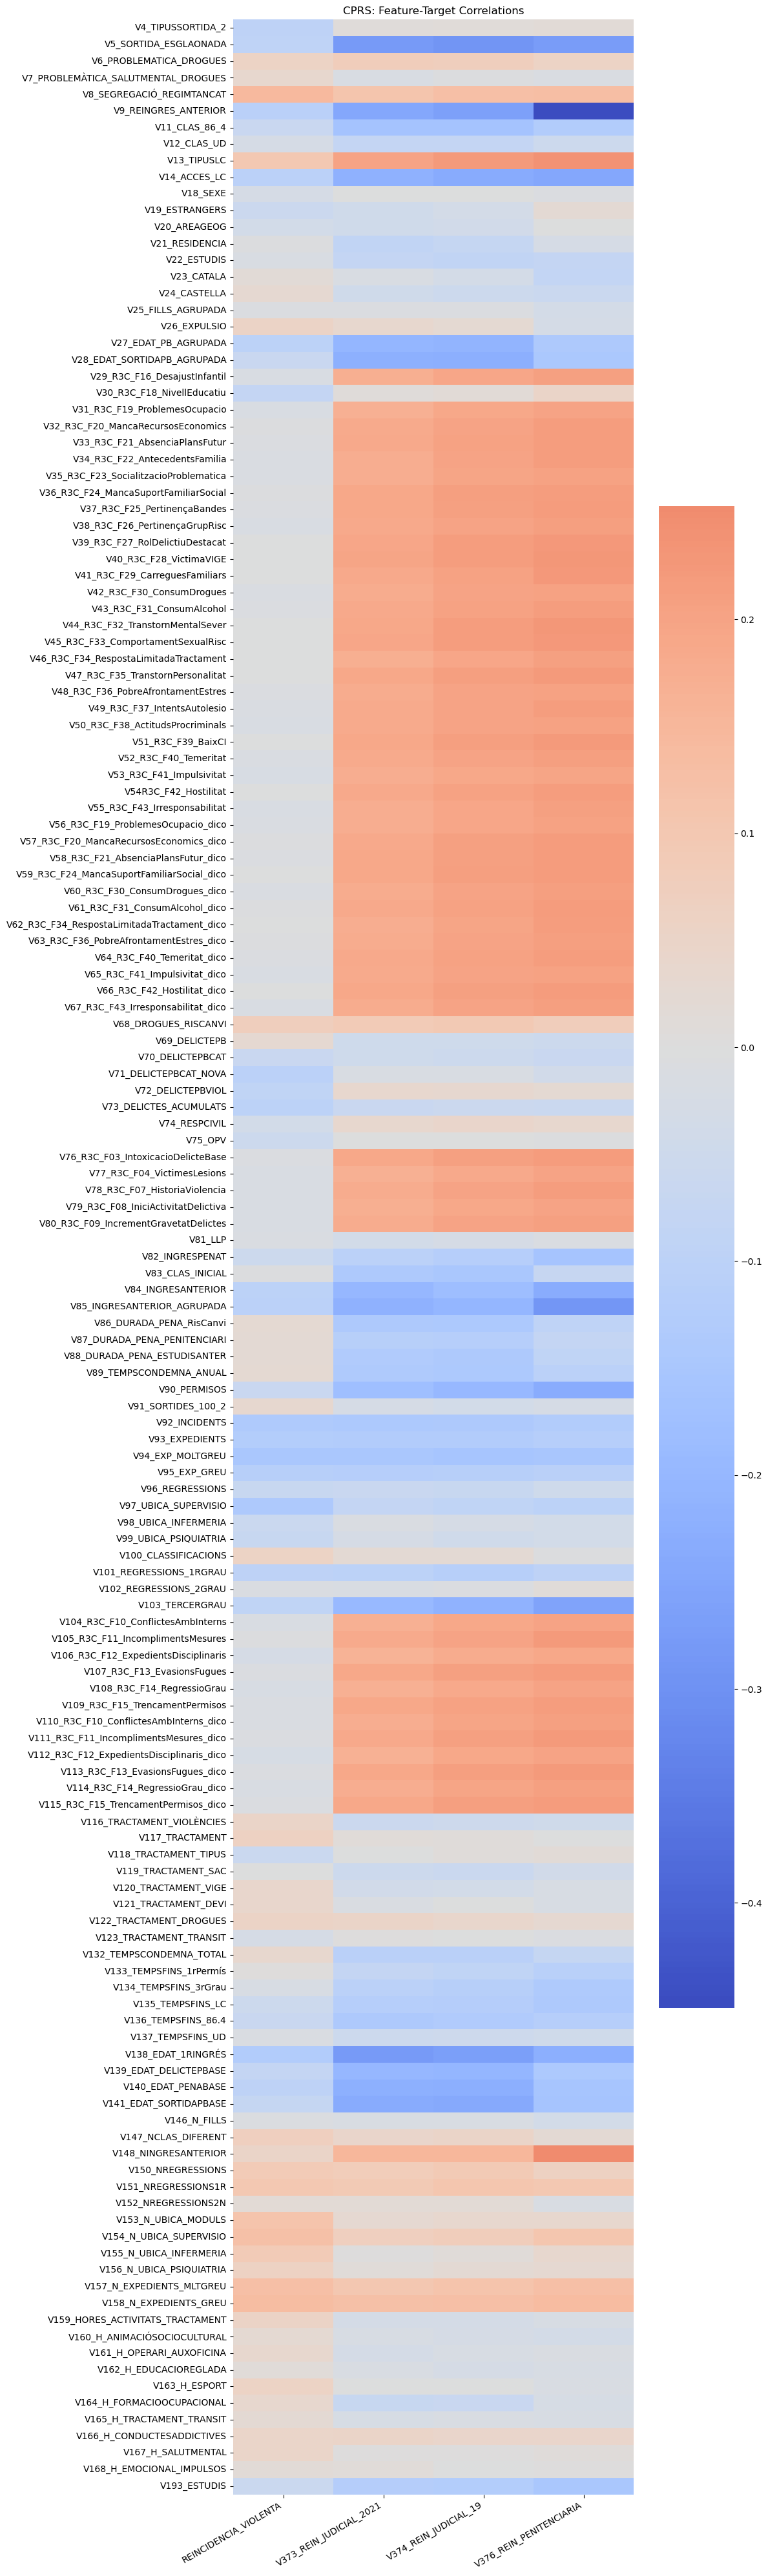

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,40))
sns.heatmap(df_corr, annot=False, cmap='coolwarm', center=0)
plt.xticks(rotation=30, ha='right')  
plt.title('CPRS: Feature-Target Correlations')
plt.tight_layout()

In [160]:
print('Most correlated variables to every target (most prone to bias): \n')

for target_col in df_corr.columns:
    
    top_10_indices = df_corr[target_col].abs().sort_values(ascending=False).head(10).index
    top_10_df = df_corr.loc[top_10_indices, [target_col]]
    
    print(top_10_df,'\n')

Most correlated variables to every target (most prone to bias): 

                           REINCIDENCIA_VIOLENTA
V94_EXP_MOLTGREU                       -0.149105
V8_SEGREGACIÓ_REGIMTANCAT               0.144815
V97_UBICA_SUPERVISIO                   -0.137789
V92_INCIDENTS                          -0.134124
V158_N_EXPEDIENTS_GREU                  0.132906
V138_EDAT_1RINGRÉS                     -0.125512
V157_N_EXPEDIENTS_MLTGREU               0.124830
V154_N_UBICA_SUPERVISIO                 0.123890
V93_EXPEDIENTS                         -0.123173
V95_EXP_GREU                           -0.114126 

                             V373_REIN_JUDICIAL_2021
V138_EDAT_1RINGRÉS                         -0.278080
V5_SORTIDA_ESGLAONADA                      -0.277411
V9_REINGRES_ANTERIOR                       -0.248419
V141_EDAT_SORTIDAPBASE                     -0.236509
V140_EDAT_PENABASE                         -0.222953
V28_EDAT_SORTIDAPB_AGRUPADA                -0.222516
V14_ACCES_LC          

### 3. Historical EDA:
Checking for potential data biases present in historical data (feedback loop data bias)

In [81]:
df_full = pd.concat([X, df[y_val]], axis=1) # full df for further anaylisis

-------

**Nationality bias**:<br>
Are non-Spanish citizens more likely to recidivate?

In [108]:
df_nation = df_full.copy()
df_nation['NATIONALITY'] = df_full['V189_NACIONALITAT'].apply(lambda x: 1 if x=='Espanya' else 0) # 1 if spanish 0 if non-spanish

In [119]:
corr = df_nation[['NATIONALITY'] + y_val].corr().loc['NATIONALITY', y_val]
corr = corr.to_frame()
print('Correlation values:\n')
corr

Correlation values:



,NATIONALITY
REINCIDENCIA_VIOLENTA,0.057977
V373_REIN_JUDICIAL_2021,0.043417
V374_REIN_JUDICIAL_19,0.033596
V376_REIN_PENITENCIARIA,-0.021452


In [117]:
df_nation.groupby('NATIONALITY')[y_val].mean()

,REINCIDENCIA_VIOLENTA,V373_REIN_JUDICIAL_2021,V374_REIN_JUDICIAL_19,V376_REIN_PENITENCIARIA
NATIONALITY,,,,
0,0.041527,0.553248,0.510382,0.221701
1,0.069045,0.596849,0.544486,0.203892


**Conclusion: no significant data bias regarding foreigners (in general) compared to Spanish citizens**

-------

**Expulsion**:<br>
Checking if the fact of prior explusion judgment reduces recidivism. 

In [143]:
df_full[df_full['V26_EXPULSIO']==1][y_val].describe()

,REINCIDENCIA_VIOLENTA,V373_REIN_JUDICIAL_2021,V374_REIN_JUDICIAL_19,V376_REIN_PENITENCIARIA
count,364.000000,364.000000,364.000000,364.000000
mean,0.079670,0.645604,0.620879,0.370879
std,0.271155,0.478988,0.485836,0.483705
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,0.000000
75%,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [144]:
df_full[df_full['V26_EXPULSIO']==2][y_val].describe()

,REINCIDENCIA_VIOLENTA,V373_REIN_JUDICIAL_2021,V374_REIN_JUDICIAL_19,V376_REIN_PENITENCIARIA
count,1129.000000,1129.000000,1129.000000,1129.000000
mean,0.029229,0.523472,0.474756,0.173605
std,0.168524,0.499670,0.499584,0.378937
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


**Conclusion: foreign inmates with a prior explusion judgment recidivate more than foreign inmates without such judgement.**

-----------

**Age bias**:<br>
Checking the correlation between age and target variables.

In [100]:
df_corr.loc[bias_set.get('age_bias')]

,REINCIDENCIA_VIOLENTA,V373_REIN_JUDICIAL_2021,V374_REIN_JUDICIAL_19,V376_REIN_PENITENCIARIA
V27_EDAT_PB_AGRUPADA,-0.098549,-0.205921,-0.212105,-0.137550
V28_EDAT_SORTIDAPB_AGRUPADA,-0.067527,-0.222516,-0.226338,-0.146407
V138_EDAT_1RINGRÉS,-0.125512,-0.278080,-0.269356,-0.226126
V139_EDAT_DELICTEPBASE,-0.079298,-0.202297,-0.205658,-0.139830
V140_EDAT_PENABASE,-0.096564,-0.222953,-0.226845,-0.154507
V141_EDAT_SORTIDAPBASE,-0.073651,-0.236509,-0.239693,-0.159506


**Conclusion: Inmates with lower age at first inprisonment are more likely to recidivate.** This applies especially to non-violent recidivism. 

Potential legal outcome: prognosis may stand against the principle of *nebis in idem*.

------

**Institutional bias**:<br>
Checking the influence of insitutionary decisions (ex. number of regressions) on recidivism perentage.

<Axes: xlabel='V150_NREGRESSIONS'>

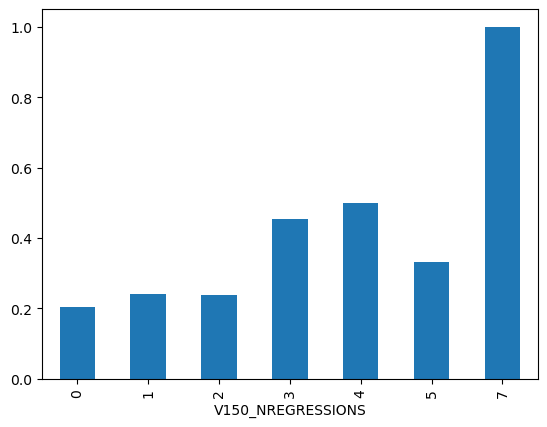

In [164]:
df.groupby('V150_NREGRESSIONS')['V376_REIN_PENITENCIARIA'].mean().plot(kind='bar')

In [169]:
df_corr.loc['V150_NREGRESSIONS']

REINCIDENCIA_VIOLENTA      0.086582
V373_REIN_JUDICIAL_2021    0.082173
V374_REIN_JUDICIAL_19      0.092136
V376_REIN_PENITENCIARIA    0.066327
Name: V150_NREGRESSIONS, dtype: float64

Conclusion: The higher the regression rate, the higher recidivism perentage (institutional bias)

### 4. Tree-based and regression risk assesment:

### X. Pre-processing for fairness augmentation (uncertainty selection):

In [99]:
bias_set.get('age_bias')

list

In [ ]:
df_full[